In [23]:
#Save the Model
import joblib

joblib.dump(model, "../models/sales_model.pkl")

['../models/sales_model.pkl']

MAE: 12766.965161028704
RMSE: 17023.622461533316
R2 Score: 0.3578052230800195


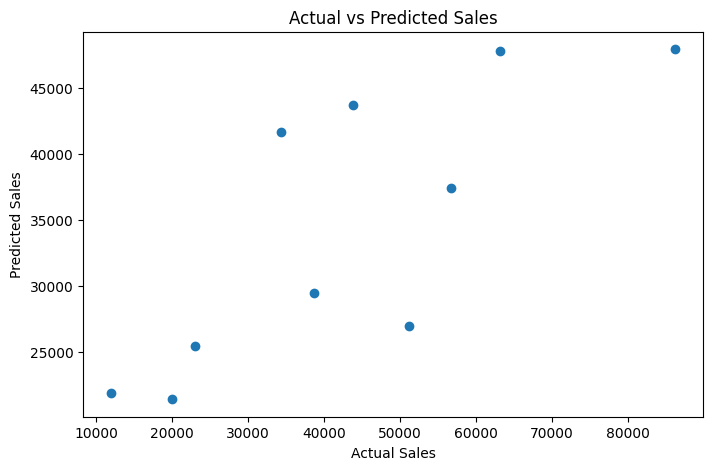

In [25]:
#module 6
#Monthly Dataset
monthly_data = (
    df.groupby(['Year','Month','Festival_Month'])
    .agg({
        'Sales': 'sum',
        'Order ID': 'nunique'
    })
    .reset_index()
)

monthly_data.rename(columns={'Order ID': 'Order_Count'}, inplace=True)

monthly_data.head()

#Previous Month Features
monthly_data = monthly_data.sort_values(by=['Year','Month'])

monthly_data['Prev_Month_Sales'] = monthly_data['Sales'].shift(1)
monthly_data['Prev_Month_Orders'] = monthly_data['Order_Count'].shift(1)

monthly_data.head()

#Remove Missing Rows
monthly_data = monthly_data.dropna()

#Define Features and Target
X = monthly_data[['Prev_Month_Sales', 'Prev_Month_Orders', 'Month', 'Festival_Month']]
y = monthly_data['Sales']

#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train Model (Linear Regression)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

#Make Predictions
y_pred = model.predict(X_test)

#Evaluate Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

#Visualize Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()




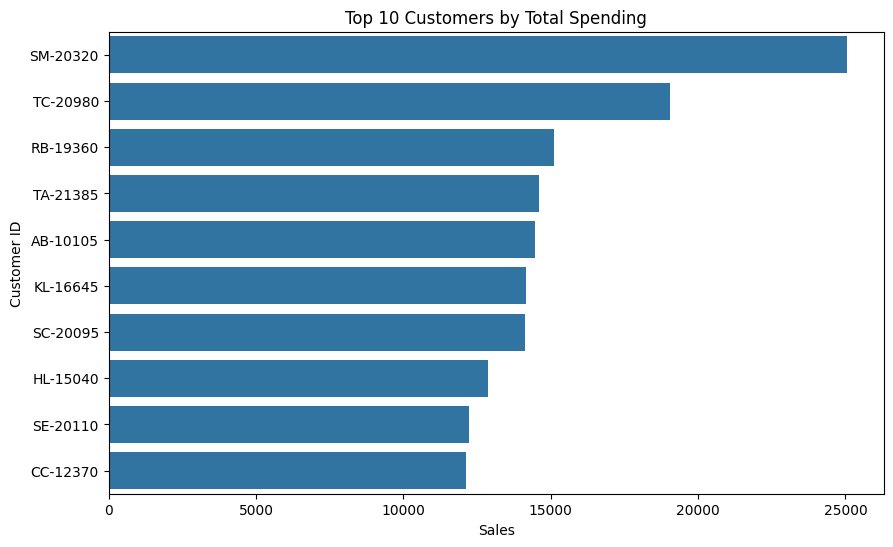

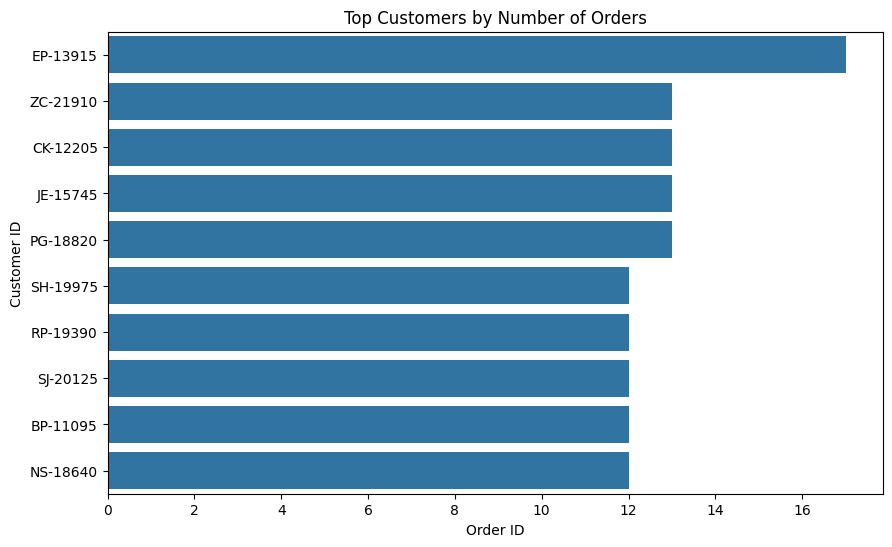

Repeat Customers: 780
One-Time Customers: 13


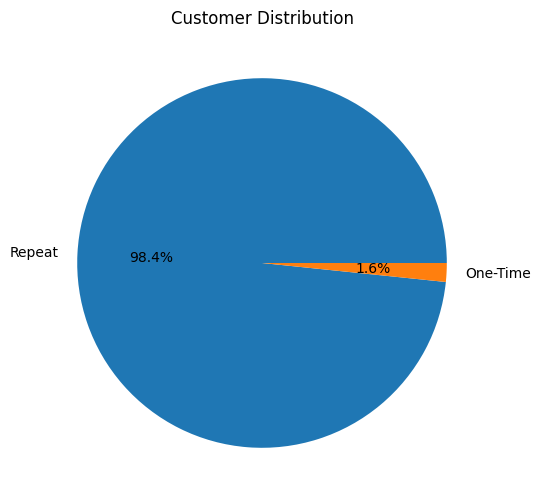

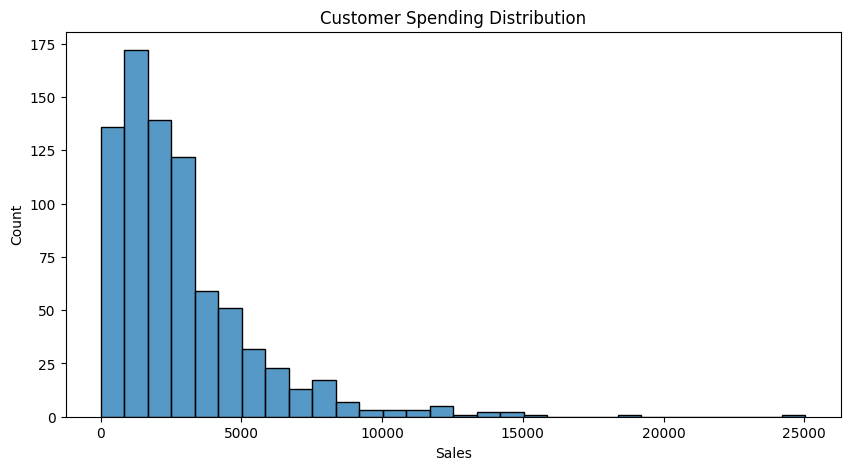

In [13]:
#module 5
#Total Spending per Customer
customer_sales = (
    df.groupby('Customer ID')['Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_sales.head(10)
top_customers = customer_sales.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_customers, x='Sales', y='Customer ID')
plt.title("Top 10 Customers by Total Spending")
plt.show()

#Number of Orders per Customer
customer_orders = (
    df.groupby('Customer ID')['Order ID']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

customer_orders.head(10)
top_orders = customer_orders.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_orders, x='Order ID', y='Customer ID')
plt.title("Top Customers by Number of Orders")
plt.show()

#Average Order Value per Customer
customer_avg = (
    df.groupby('Customer ID')['Sales']
    .mean()
    .reset_index()
)

customer_avg.head()

#Repeat vs One-Time Customers
customer_order_count = df.groupby('Customer ID')['Order ID'].nunique()

repeat_customers = (customer_order_count > 1).sum()
one_time_customers = (customer_order_count == 1).sum()

print("Repeat Customers:", repeat_customers)
print("One-Time Customers:", one_time_customers)
import matplotlib.pyplot as plt

labels = ['Repeat', 'One-Time']
values = [repeat_customers, one_time_customers]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Customer Distribution")
plt.show()

#Customer Revenue Distribution
plt.figure(figsize=(10,5))
sns.histplot(customer_sales['Sales'], bins=30)
plt.title("Customer Spending Distribution")
plt.show()

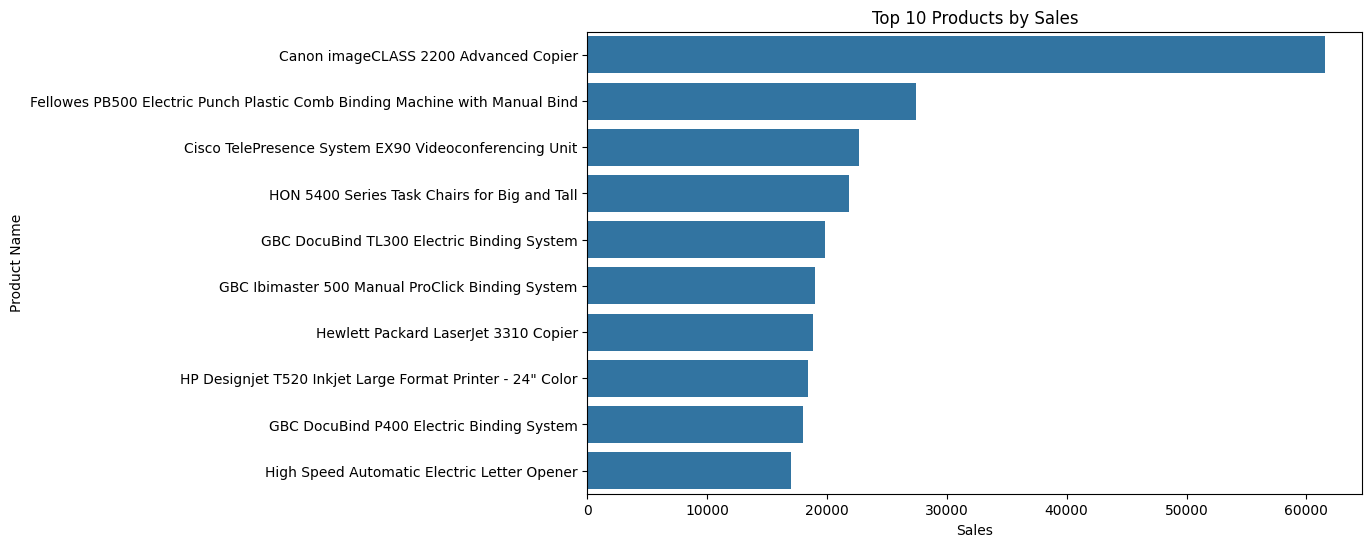

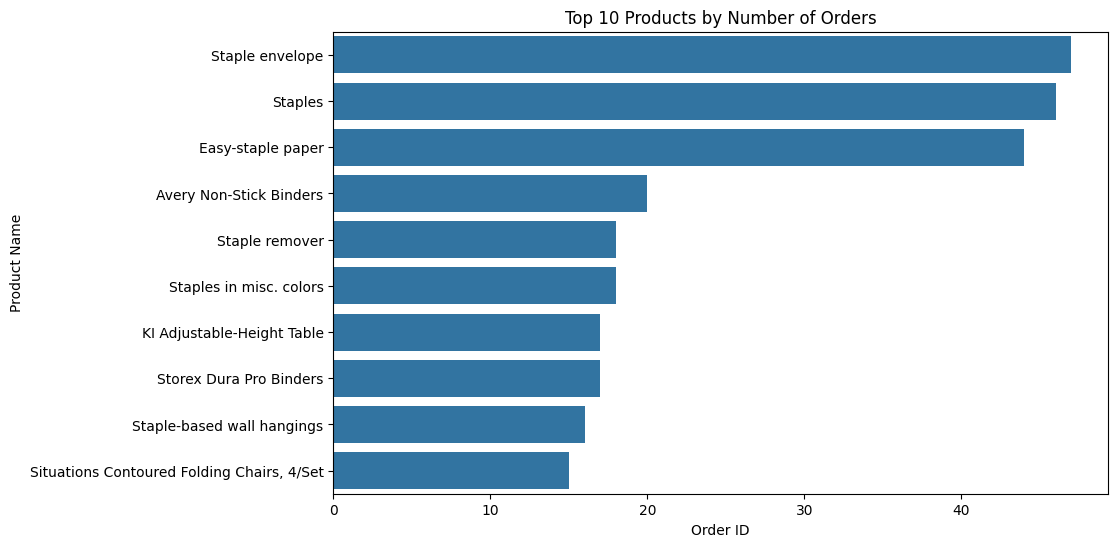

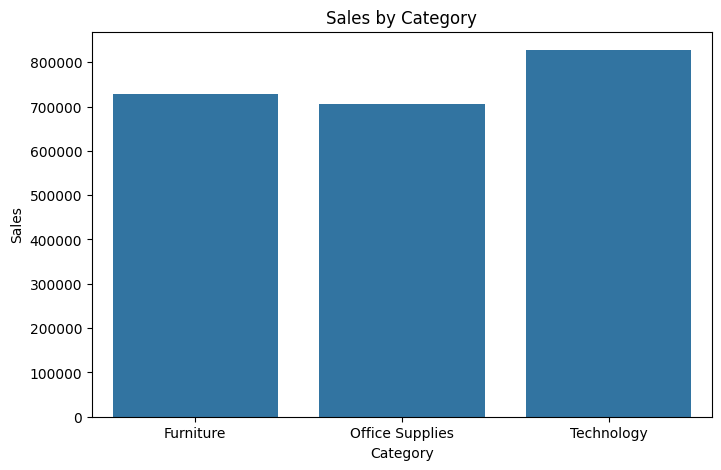

In [12]:
#module 4
#top prd by revenue
top_products_sales = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_sales
plt.figure(figsize=(10,6))
sns.barplot(data=top_products_sales, x='Sales', y='Product Name')
plt.title("Top 10 Products by Sales")
plt.show()

#top prd by order count
top_products_orders = (
    df.groupby('Product Name')['Order ID']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_orders
plt.figure(figsize=(10,6))
sns.barplot(data=top_products_orders, x='Order ID', y='Product Name')
plt.title("Top 10 Products by Number of Orders")
plt.show()

#category wise
category_sales = (
    df.groupby('Category')['Sales']
    .sum()
    .reset_index()
)

category_sales
plt.figure(figsize=(8,5))
sns.barplot(data=category_sales, x='Category', y='Sales')
plt.title("Sales by Category")
plt.show()




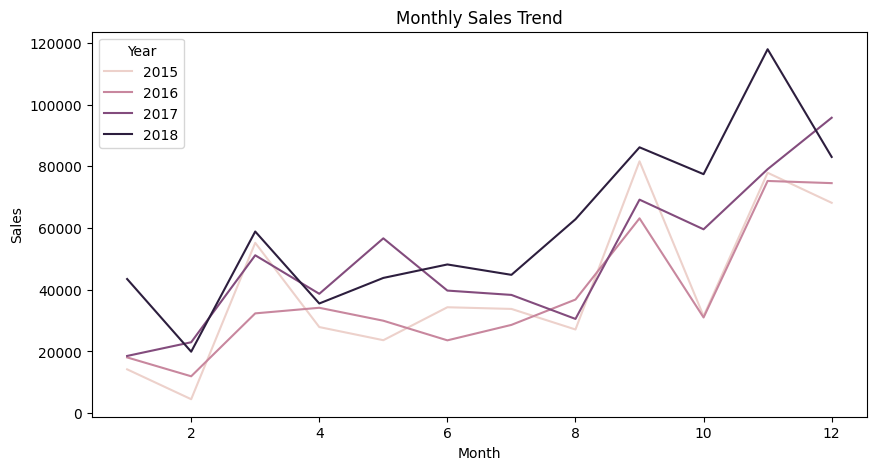

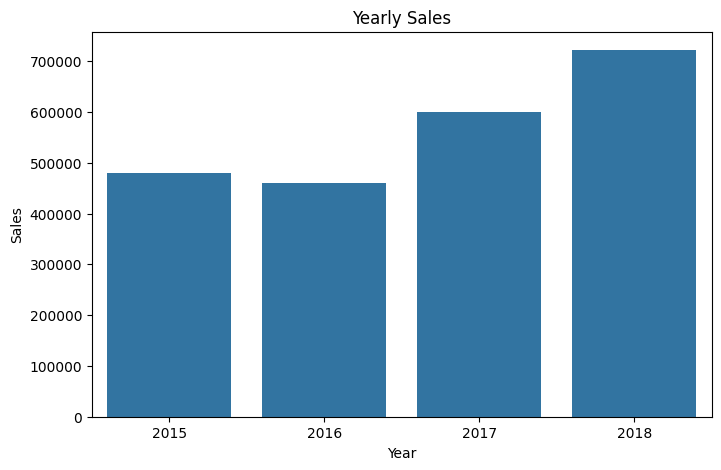

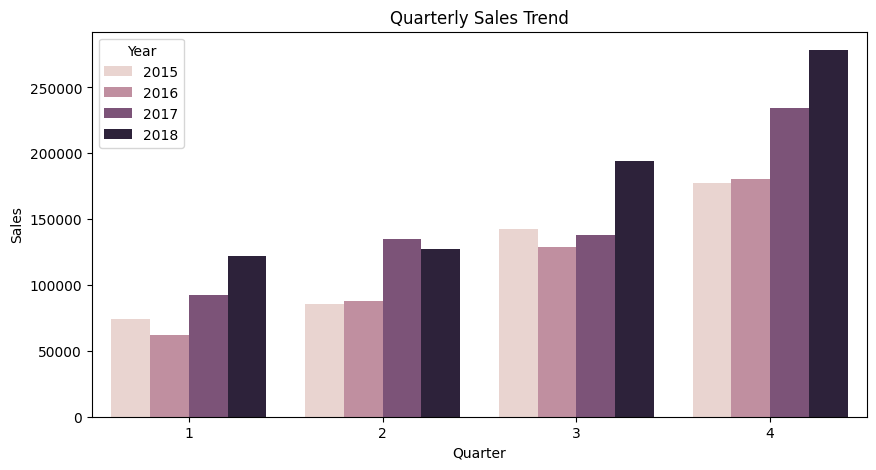

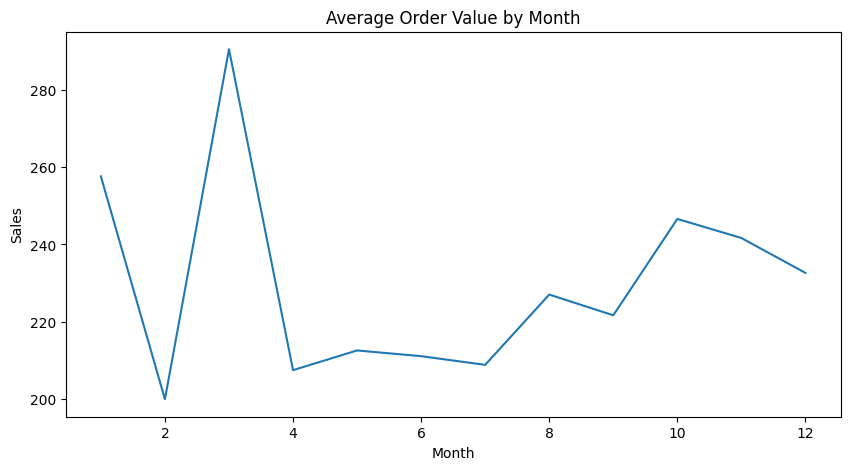

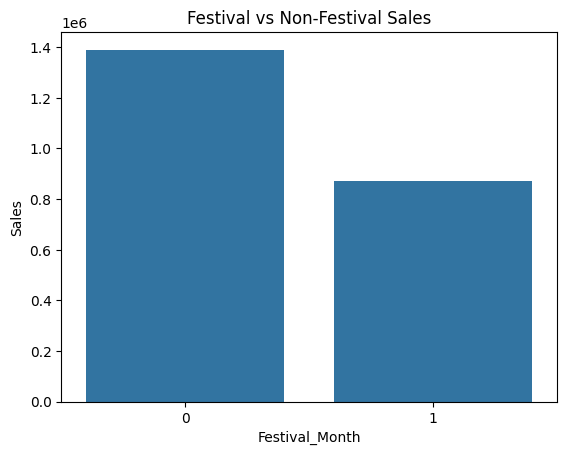

In [24]:
#module 3 Revenue Trend Analysis
#monthly sales trend
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales.head()
#virtualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year')
plt.title("Monthly Sales Trend")
plt.show()

#yearly sales trend
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
yearly_sales
plt.figure(figsize=(8,5))
sns.barplot(data=yearly_sales, x='Year', y='Sales')
plt.title("Yearly Sales")
plt.show()

#quater sales trend
quarterly_sales = df.groupby(['Year','Quarter'])['Sales'].sum().reset_index()
quarterly_sales.head()
plt.figure(figsize=(10,5))
sns.barplot(data=quarterly_sales, x='Quarter', y='Sales', hue='Year')
plt.title("Quarterly Sales Trend")
plt.show()

#avg order value by month
avg_order = df.groupby('Month')['Sales'].mean().reset_index()
avg_order
plt.figure(figsize=(10,5))
sns.lineplot(data=avg_order, x='Month', y='Sales')
plt.title("Average Order Value by Month")
plt.show()

#festival vs non
festival_sales = df.groupby('Festival_Month')['Sales'].sum().reset_index()
festival_sales
sns.barplot(data=festival_sales, x='Festival_Month', y='Sales')
plt.title("Festival vs Non-Festival Sales")
plt.show()


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Month_Name', 'Quarter',
       'Festival_Month', 'Order_Value'],
      dtype='object')

In [5]:
#module 2 check
df.head()
df.info()
df.columns
df[['Order Date', 'Year', 'Month', 'Month_Name', 'Quarter', 'Festival_Month', 'Order_Value']].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9800 non-null   int64         
 1   Order ID        9800 non-null   object        
 2   Order Date      9800 non-null   datetime64[ns]
 3   Ship Date       9800 non-null   object        
 4   Ship Mode       9800 non-null   object        
 5   Customer ID     9800 non-null   object        
 6   Customer Name   9800 non-null   object        
 7   Segment         9800 non-null   object        
 8   Country         9800 non-null   object        
 9   City            9800 non-null   object        
 10  State           9800 non-null   object        
 11  Postal Code     9789 non-null   float64       
 12  Region          9800 non-null   object        
 13  Product ID      9800 non-null   object        
 14  Category        9800 non-null   object        
 15  Sub-

,Order Date,Year,Month,Month_Name,Quarter,Festival_Month,Order_Value
0,2017-11-08,2017,11,November,4,1,261.9600
1,2017-11-08,2017,11,November,4,1,731.9400
2,2017-06-12,2017,6,June,2,0,14.6200
3,2016-10-11,2016,10,October,4,1,957.5775
4,2016-10-11,2016,10,October,4,1,22.3680


In [4]:
#order value
df['Order_Value'] = df['Sales']

In [3]:
#festival 
festival_months = [10, 11, 12]
df['Festival_Month'] = df['Month'].apply(lambda x: 1 if x in festival_months else 0)
df[['Month','Festival_Month']].head()

,Month,Festival_Month
0,11,1
1,11,1
2,6,0
3,10,1
4,10,1


In [2]:
df.isnull().sum()
df.duplicated().sum()
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df.info()
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter
df[['Order Date', 'Year', 'Month', 'Month_Name', 'Quarter']].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

,Order Date,Year,Month,Month_Name,Quarter
0,2017-11-08,2017,11,November,4
1,2017-11-08,2017,11,November,4
2,2017-06-12,2017,6,June,2
3,2016-10-11,2016,10,October,4
4,2016-10-11,2016,10,October,4


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/superstore.csv")
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64